# Problema 1 - Red neuronal para predecir compra de casa

**Objetivo:** predecir si un cliente comprará una casa (`decision = 1`) o no (`decision = 0`) usando una red neuronal artificial sobre el dataset `global_house_purchase_dataset.csv`.



## 1. Relación con los notebooks de ejemplo

Para resolver este problema se tomó como base la lógica de los siguientes notebooks:

- `Keras_Functional_API`: sirve para construir una red con `keras.Input`, capas `Dense`, `Dropout`, `model.compile`, `model.fit`, validación y `model.save`.
- `Analisis_de_Sentimiento`: es muy útil porque también es un problema de **clasificación binaria**. De ahí se retoma la idea de usar salida `sigmoid`, `binary_crossentropy`, callbacks y validación.
- `PretrainedModel_and_FineTunning`, `Conv2DPerrosyGatos`, `ResidualConv2D`, `ResidualConv2DBlocks2` y `SeparableConv2D_y_AumentoDatos`: son notebooks pensados para imágenes. Sus arquitecturas con `Conv2D`, bloques residuales, aumento de datos o modelos preentrenados no son la mejor opción para este dataset, porque aquí los datos son tabulares: país, ciudad, tipo de propiedad, precio, salario, préstamo, etc.

Por eso, para este primer problema se usa una red neuronal tipo **MLP** o red densa, que es la arquitectura más natural para datos tabulares.

## 2. Importar librerías y configurar semilla

Usaremos:

- `pandas` y `numpy` para manipular datos.
- `scikit-learn` para separar train/validation/test y preprocesar variables numéricas/categóricas.
- `tensorflow.keras` para construir y entrenar la red neuronal.
- `matplotlib` para generar las gráficas de `loss` y `accuracy`.

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 3. Cargar el archivo CSV



In [2]:
DATA_PATH = "global_house_purchase_dataset.csv"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("No encontré el CSV en la carpeta actual. Sube el archivo global_house_purchase_dataset.csv:")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError(
            "No se encontró el CSV. Sube global_house_purchase_dataset.csv al entorno de Colab."
        ) from e

df = pd.read_csv(DATA_PATH)

print("Dimensiones del dataset:", df.shape)
display(df.head())

No encontré el CSV en la carpeta actual. Sube el archivo global_house_purchase_dataset.csv:


Saving global_house_purchase_dataset (1).csv to global_house_purchase_dataset (1).csv
Dimensiones del dataset: (200000, 25)


,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0


## 4. Exploración inicial del dataset

La variable objetivo es `decision`.

- `decision = 1`: el cliente compra la casa.
- `decision = 0`: el cliente no compra la casa.

También revisamos valores nulos, tipos de datos y balance de clases.

Columnas:
['property_id', 'country', 'city', 'property_type', 'furnishing_status', 'property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score', 'decision']

Tipos de datos:


,dtype
property_id,int64
country,object
city,object
property_type,object
furnishing_status,object
property_size_sqft,int64
price,int64
constructed_year,int64
previous_owners,int64
rooms,int64



Valores nulos por columna:


,missing_values
property_id,0
country,0
city,0
property_type,0
furnishing_status,0
property_size_sqft,0
price,0
constructed_year,0
previous_owners,0
rooms,0



Distribución de la variable objetivo:


,count
decision,
0,153932
1,46068


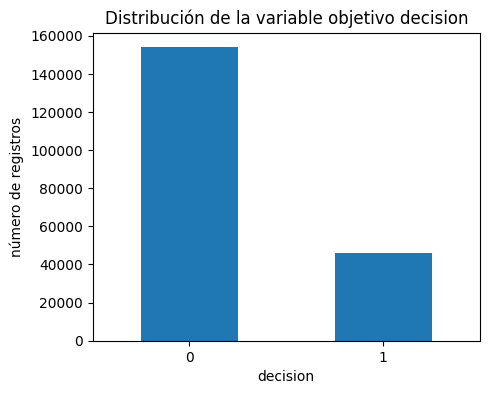

Porcentaje por clase:


,percentage
decision,
0,76.97
1,23.03


In [3]:
target_col = "decision"
id_col = "property_id"

print("Columnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))

print("\nValores nulos por columna:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDistribución de la variable objetivo:")
target_counts = df[target_col].value_counts().sort_index()
display(target_counts.to_frame("count"))

plt.figure(figsize=(5, 4))
target_counts.plot(kind="bar")
plt.title("Distribución de la variable objetivo decision")
plt.xlabel("decision")
plt.ylabel("número de registros")
plt.xticks(rotation=0)
plt.show()

print("Porcentaje por clase:")
display((target_counts / len(df) * 100).round(2).to_frame("percentage"))

## 5. Separación de variables y conjuntos train / validation / test

Usaremos una separación estratificada para conservar la proporción de clientes que compran y no compran.

- 70% entrenamiento
- 15% validación
- 15% prueba final

El campo `property_id` se elimina porque es solo un identificador y puede meter ruido al modelo.

In [4]:
# Separamos X e y.
drop_cols = [target_col]
if id_col in df.columns:
    drop_cols.append(id_col)

X = df.drop(columns=drop_cols)
y = df[target_col].astype("int32")

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Variables categóricas:", categorical_cols)
print("Variables numéricas:", numeric_cols)

# 70% train, 30% temporal.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Del 30% temporal, la mitad validation y la mitad test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Variables categóricas: ['country', 'city', 'property_type', 'furnishing_status']
Variables numéricas: ['property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score']
Train: (140000, 23) (140000,)
Validation: (30000, 23) (30000,)
Test: (30000, 23) (30000,)


## 6. Preprocesamiento

La red neuronal necesita datos numéricos.

Por eso aplicamos:

- `StandardScaler` a variables numéricas.
- `OneHotEncoder` a variables categóricas como país, ciudad, tipo de propiedad y estado de amueblado.

Este preprocesamiento se ajusta solo con el conjunto de entrenamiento para evitar fuga de información.

In [5]:
# Compatibilidad entre versiones de scikit-learn:
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", one_hot, categorical_cols)
    ],
    remainder="drop"
)

X_train_pre = preprocessor.fit_transform(X_train)
X_val_pre = preprocessor.transform(X_val)
X_test_pre = preprocessor.transform(X_test)

# Por si alguna versión regresa matriz sparse:
if hasattr(X_train_pre, "toarray"):
    X_train_pre = X_train_pre.toarray()
    X_val_pre = X_val_pre.toarray()
    X_test_pre = X_test_pre.toarray()

X_train_pre = X_train_pre.astype("float32")
X_val_pre = X_val_pre.astype("float32")
X_test_pre = X_test_pre.astype("float32")

y_train_np = y_train.to_numpy().astype("float32")
y_val_np = y_val.to_numpy().astype("float32")
y_test_np = y_test.to_numpy().astype("float32")

input_dim = X_train_pre.shape[1]
print("Número de variables después del preprocesamiento:", input_dim)
print("X_train_pre:", X_train_pre.shape)

Número de variables después del preprocesamiento: 81
X_train_pre: (140000, 81)


## 7. Balance de clases

El dataset no está perfectamente balanceado: normalmente hay más clientes con `decision = 0` que con `decision = 1`.

Para reducir ese sesgo, calculamos `class_weight`, que le da mayor peso a la clase minoritaria durante el entrenamiento.

In [6]:
classes = np.unique(y_train_np)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np
)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:", class_weight)

Class weights: {0: 0.6496399138763086, 1: 2.1706772513024064}


## 8. Funciones para crear, entrenar y graficar modelos

Se entrenarán varios modelos para cumplir con la parte de la tarea que pide observar gráficas de `loss` y `accuracy` en varios entrenamientos.

Cada experimento guarda:

- Modelo `.keras`
- Historial `.csv`
- Gráfica `.png` con `loss` y `accuracy`
- Métricas finales en validation y test

In [8]:
ARTIFACT_DIR = "artifacts_problema1"
GRAPH_DIR = os.path.join(ARTIFACT_DIR, "graficas_entrenamiento")
MODEL_DIR = os.path.join(ARTIFACT_DIR, "modelos")
HISTORY_DIR = os.path.join(ARTIFACT_DIR, "historias")

for d in [ARTIFACT_DIR, GRAPH_DIR, MODEL_DIR, HISTORY_DIR]:
    os.makedirs(d, exist_ok=True)


def build_mlp(input_dim, hidden_layers=(64, 32), dropout=0.20, lr=0.001, batch_norm=False):
    inputs = keras.Input(shape=(input_dim,), name="features")
    x = inputs

    for units in hidden_layers:
        x = layers.Dense(units, activation="relu")(x)
        if batch_norm:
            x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="decision_probability")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model


def plot_history(history, model_name):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"Loss - {model_name}")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True)
    loss_path = os.path.join(GRAPH_DIR, f"{model_name}_loss.png")
    plt.savefig(loss_path, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(hist["accuracy"], label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title(f"Accuracy - {model_name}")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)
    acc_path = os.path.join(GRAPH_DIR, f"{model_name}_accuracy.png")
    plt.savefig(acc_path, dpi=150, bbox_inches="tight")
    plt.show()

    return loss_path, acc_path


def train_experiment(model_name, hidden_layers, dropout, lr, batch_norm=False, epochs=25, batch_size=512):
    print(f"\n===== Entrenando {model_name} =====")

    model = build_mlp(
        input_dim=input_dim,
        hidden_layers=hidden_layers,
        dropout=dropout,
        lr=lr,
        batch_norm=batch_norm
    )

    model.summary()

    model_path = os.path.join(MODEL_DIR, f"{model_name}.keras")

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            model_path,
            save_best_only=True,
            monitor="val_auc",
            mode="max"
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train_pre,
        y_train_np,
        validation_data=(X_val_pre, y_val_np),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )

    hist_df = pd.DataFrame(history.history)
    history_path = os.path.join(HISTORY_DIR, f"{model_name}_history.csv")
    hist_df.to_csv(history_path, index=False)

    loss_path, acc_path = plot_history(history, model_name)

    val_metrics = model.evaluate(X_val_pre, y_val_np, verbose=0)
    test_metrics = model.evaluate(X_test_pre, y_test_np, verbose=0)

    metrics_names = model.metrics_names

    result = {
        "model": model_name,
        "hidden_layers": str(hidden_layers),
        "dropout": dropout,
        "learning_rate": lr,
        "batch_norm": batch_norm,
        "model_path": model_path,
        "history_path": history_path,
        "loss_graph": loss_path,
        "accuracy_graph": acc_path
    }

    for metric_name, value in zip(metrics_names, val_metrics):
        result[f"val_{metric_name}"] = value

    for metric_name, value in zip(metrics_names, test_metrics):
        result[f"test_{metric_name}"] = value

    return result

## 9. Entrenar varios modelos




===== Entrenando mlp_pequena =====


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 81)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decision_probability (Dense)    │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8663 - auc: 0.9563 - loss: 0.2718 - val_accuracy: 0.9550 - val_auc: 0.9941 - val_loss: 0.1069
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9580 - auc: 0.9936 - loss: 0.0949 - val_accuracy: 0.9811 - val_auc: 0.9985 - val_loss: 0.0563
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9792 - auc: 0.9982 - loss: 0.0506 - val_accuracy: 0.9942 - val_auc: 0.9998 - val_loss: 0.0200
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9908 - auc: 0.9995 - loss: 0.0243 - val_accuracy: 0.9969 - val_auc: 1.0000 - val_loss: 0.0084
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9945 - auc: 0.9998 - loss: 0.0147 - val_accuracy: 0.9979 - val_auc: 1.0000 - val_loss: 0.0054
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9957 - auc: 0.9999 - loss: 0.0111 - val_accuracy: 0.9975 - val_auc: 1.0000 - val_loss: 0.0053
Epoch 7/25
274/274 ━━━━━━━━━━━━━━━━━━━

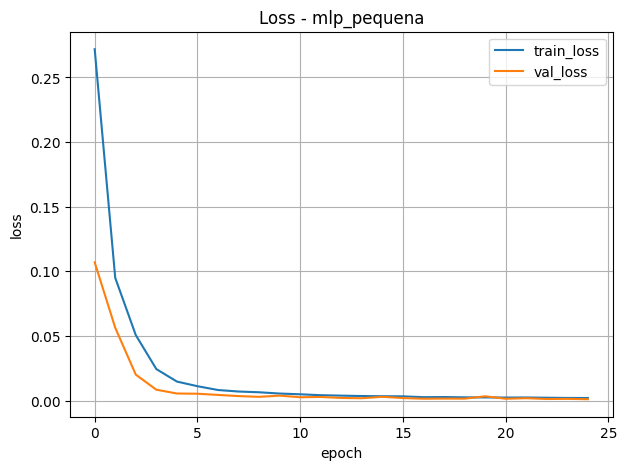

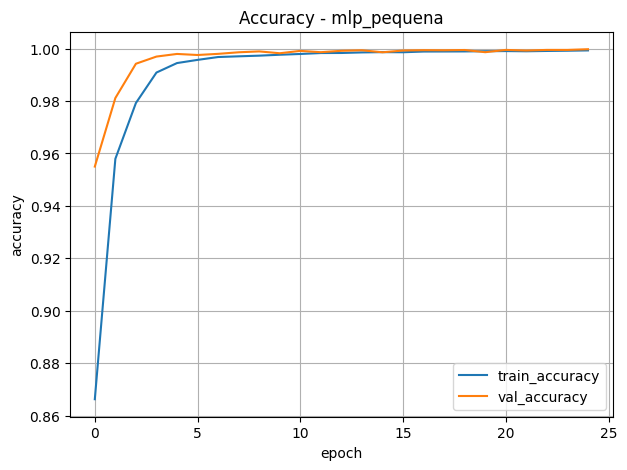


===== Entrenando mlp_mediana =====


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 81)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decision_probability (Dense)    │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,865 (81.50 KB)

 Trainable params: 20,865 (81.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8999 - auc: 0.9687 - loss: 0.2231 - val_accuracy: 0.9687 - val_auc: 0.9967 - val_loss: 0.0790
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9695 - auc: 0.9960 - loss: 0.0727 - val_accuracy: 0.9944 - val_auc: 0.9998 - val_loss: 0.0193
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9905 - auc: 0.9993 - loss: 0.0256 - val_accuracy: 0.9974 - val_auc: 1.0000 - val_loss: 0.0074
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9949 - auc: 0.9998 - loss: 0.0128 - val_accuracy: 0.9977 - val_auc: 1.0000 - val_loss: 0.0060
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9965 - auc: 0.9999 - loss: 0.0091 - val_accuracy: 0.9986 - val_auc: 1.0000 - val_loss: 0.0035
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9971 - auc: 0.9999 - loss: 0.0071 - val_accuracy: 0.9981 - val_auc: 1.0000 - val_loss: 0.0044
Epoch 7/25
274/274 ━━━━━━━━━━━━━━━━━━━

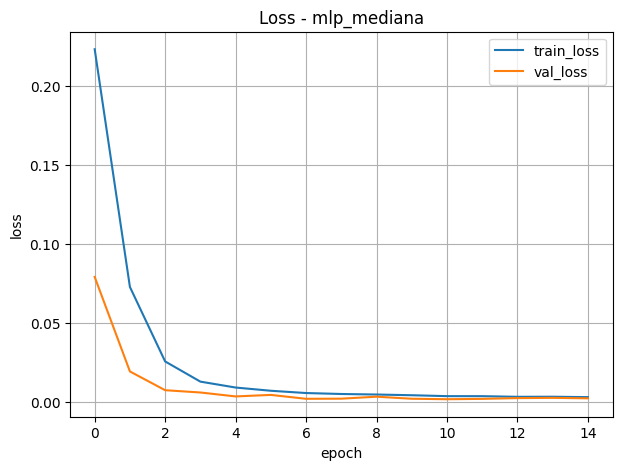

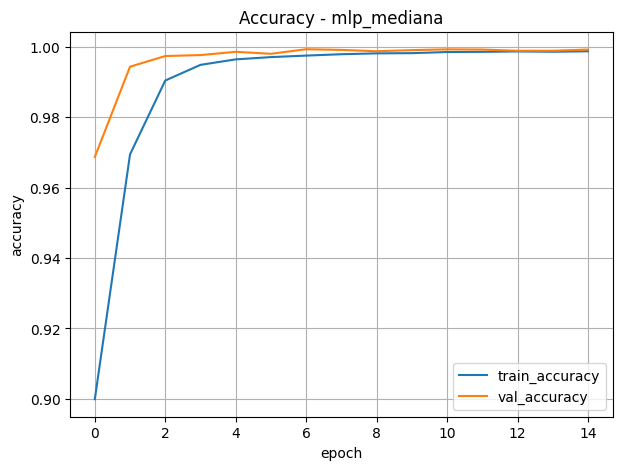


===== Entrenando mlp_batchnorm =====


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 81)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decision_probability (Dense)    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,585 (76.50 KB)

 Trainable params: 19,201 (75.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8621 - auc: 0.9669 - loss: 0.2508 - val_accuracy: 0.9684 - val_auc: 0.9941 - val_loss: 0.1081
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9590 - auc: 0.9942 - loss: 0.0960 - val_accuracy: 0.9909 - val_auc: 0.9991 - val_loss: 0.0431
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9807 - auc: 0.9982 - loss: 0.0504 - val_accuracy: 0.9962 - val_auc: 0.9999 - val_loss: 0.0163
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9903 - auc: 0.9993 - loss: 0.0277 - val_accuracy: 0.9970 - val_auc: 1.0000 - val_loss: 0.0090
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9941 - auc: 0.9997 - loss: 0.0175 - val_accuracy: 0.9980 - val_auc: 1.0000 - val_loss: 0.0058
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9957 - auc: 0.9998 - loss: 0.0124 - val_accuracy: 0.9975 - val_auc: 1.0000 - val_loss: 0.0059
Epoch 7/25
274/274 ━━━━━━━━━━━━━━━━━━━

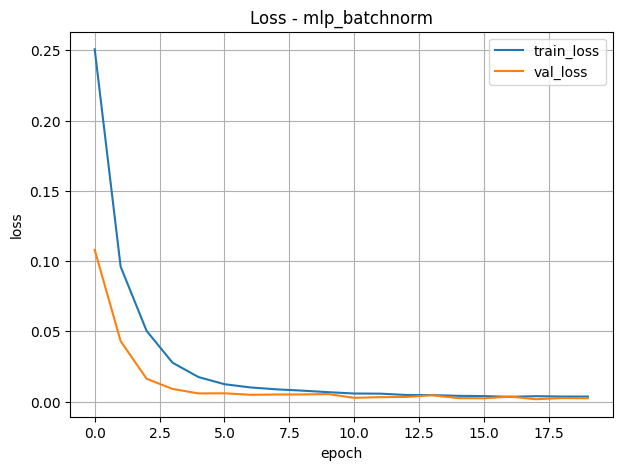

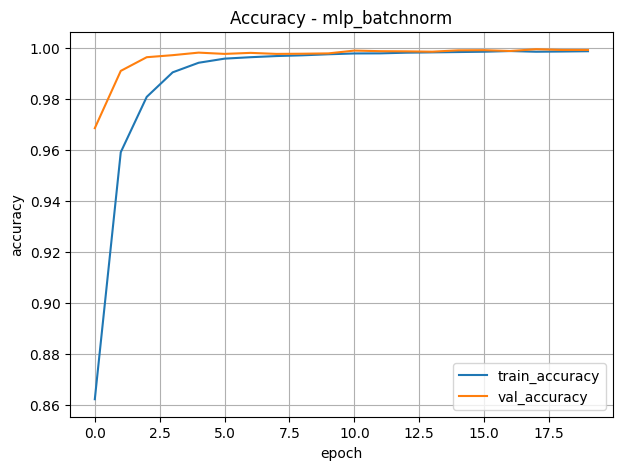

,model,hidden_layers,dropout,learning_rate,batch_norm,model_path,history_path,loss_graph,accuracy_graph,val_loss,val_compile_metrics,test_loss,test_compile_metrics
0,mlp_pequena,"(64, 32)",0.20,0.0010,False,artifacts_problema1/modelos/mlp_pequena.keras,artifacts_problema1/historias/mlp_pequena_hist...,artifacts_problema1/graficas_entrenamiento/mlp...,artifacts_problema1/graficas_entrenamiento/mlp...,0.001183,0.999467,0.001674,0.999267
1,mlp_mediana,"(128, 64, 32)",0.30,0.0010,False,artifacts_problema1/modelos/mlp_mediana.keras,artifacts_problema1/historias/mlp_mediana_hist...,artifacts_problema1/graficas_entrenamiento/mlp...,artifacts_problema1/graficas_entrenamiento/mlp...,0.002001,0.999100,0.002617,0.998900
2,mlp_batchnorm,"(128, 64)",0.25,0.0008,True,artifacts_problema1/modelos/mlp_batchnorm.keras,artifacts_problema1/historias/mlp_batchnorm_hi...,artifacts_problema1/graficas_entrenamiento/mlp...,artifacts_problema1/graficas_entrenamiento/mlp...,0.002516,0.998933,0.002738,0.998933


Resumen guardado en: artifacts_problema1/resumen_experimentos.csv


In [9]:
EPOCHS = 25
BATCH_SIZE = 512

experiments = [
    {
        "model_name": "mlp_pequena",
        "hidden_layers": (64, 32),
        "dropout": 0.20,
        "lr": 0.001,
        "batch_norm": False
    },
    {
        "model_name": "mlp_mediana",
        "hidden_layers": (128, 64, 32),
        "dropout": 0.30,
        "lr": 0.001,
        "batch_norm": False
    },
    {
        "model_name": "mlp_batchnorm",
        "hidden_layers": (128, 64),
        "dropout": 0.25,
        "lr": 0.0008,
        "batch_norm": True
    }
]

results = []

for exp in experiments:
    result = train_experiment(
        model_name=exp["model_name"],
        hidden_layers=exp["hidden_layers"],
        dropout=exp["dropout"],
        lr=exp["lr"],
        batch_norm=exp["batch_norm"],
        epochs=EPOCHS,
        batch_size=BATCH_SIZE
    )
    results.append(result)

results_df = pd.DataFrame(results)
results_path = os.path.join(ARTIFACT_DIR, "resumen_experimentos.csv")
results_df.to_csv(results_path, index=False)

display(results_df)
print("Resumen guardado en:", results_path)

In [10]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=results_df)

https://docs.google.com/spreadsheets/d/18m6twLYLh8EEk3H_j8tbSEMCdooK2JI6Z36EP_tcdII/edit#gid=0


## 10. Evaluación del mejor modelo

Elegimos el mejor modelo por `val_auc`, porque el problema tiene clases desbalanceadas. También revisamos accuracy, matriz de confusión y reporte de clasificación.

La columna val_auc no existe. Se va a recalcular usando los modelos guardados.


,model,hidden_layers,dropout,learning_rate,batch_norm,model_path,history_path,loss_graph,accuracy_graph,val_loss,val_compile_metrics,test_loss,test_compile_metrics,val_auc
0,mlp_pequena,"(64, 32)",0.20,0.0010,False,artifacts_problema1/modelos/mlp_pequena.keras,artifacts_problema1/historias/mlp_pequena_hist...,artifacts_problema1/graficas_entrenamiento/mlp...,artifacts_problema1/graficas_entrenamiento/mlp...,0.001183,0.999467,0.001674,0.999267,1.000000
1,mlp_mediana,"(128, 64, 32)",0.30,0.0010,False,artifacts_problema1/modelos/mlp_mediana.keras,artifacts_problema1/historias/mlp_mediana_hist...,artifacts_problema1/graficas_entrenamiento/mlp...,artifacts_problema1/graficas_entrenamiento/mlp...,0.002001,0.999100,0.002617,0.998900,0.999999
2,mlp_batchnorm,"(128, 64)",0.25,0.0008,True,artifacts_problema1/modelos/mlp_batchnorm.keras,artifacts_problema1/historias/mlp_batchnorm_hi...,artifacts_problema1/graficas_entrenamiento/mlp...,artifacts_problema1/graficas_entrenamiento/mlp...,0.002516,0.998933,0.002738,0.998933,0.999999


Mejor modelo: mlp_pequena
Ruta: artifacts_problema1/modelos/mlp_pequena.keras
Mejor val_auc: 0.9999996114117099

AUC test: 0.9999984519143927

Classification report:
              precision    recall  f1-score   support

         0.0     1.0000    0.9990    0.9995     23090
         1.0     0.9968    1.0000    0.9984      6910

    accuracy                         0.9993     30000
   macro avg     0.9984    0.9995    0.9990     30000
weighted avg     0.9993    0.9993    0.9993     30000



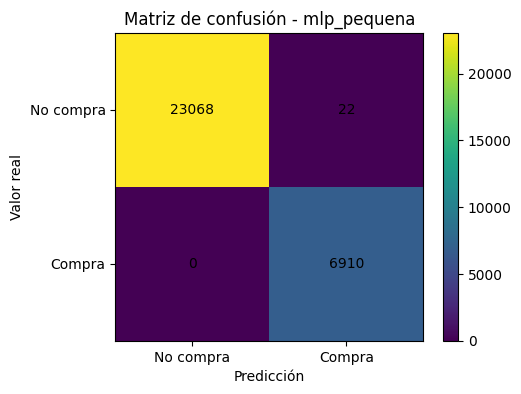

Matriz de confusión guardada en: artifacts_problema1/graficas_entrenamiento/mlp_pequena_confusion_matrix.png


In [15]:
# Recalcular val_auc si no existe en results_df
if "val_auc" not in results_df.columns:
    print("La columna val_auc no existe. Se va a recalcular usando los modelos guardados.")

    val_auc_list = []

    for _, row in results_df.iterrows():
        model_path = row["model_path"]
        temp_model = keras.models.load_model(model_path)

        val_prob = temp_model.predict(X_val_pre, verbose=0).ravel()
        auc_value = roc_auc_score(y_val_np, val_prob)

        val_auc_list.append(auc_value)

    results_df["val_auc"] = val_auc_list

    # Guardamos otra vez el resumen actualizado
    results_df.to_csv(results_path, index=False)

display(results_df)

# Elegimos el mejor modelo por AUC de validación.
best_row = results_df.sort_values(by="val_auc", ascending=False).iloc[0]

best_model_name = best_row["model"]
best_model_path = best_row["model_path"]

print("Mejor modelo:", best_model_name)
print("Ruta:", best_model_path)
print("Mejor val_auc:", best_row["val_auc"])

best_model = keras.models.load_model(best_model_path)

# Predicciones sobre test
y_prob = best_model.predict(X_test_pre, verbose=0).ravel()
y_pred = (y_prob >= 0.50).astype("int32")

print("\nAUC test:", roc_auc_score(y_test_np, y_prob))

print("\nClassification report:")
print(classification_report(y_test_np, y_pred, digits=4))

# Matriz de confusión
cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0, 1], ["No compra", "Compra"])
plt.yticks([0, 1], ["No compra", "Compra"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()

cm_path = os.path.join(GRAPH_DIR, f"{best_model_name}_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Matriz de confusión guardada en:", cm_path)

## 11. Ejemplos de predicción

Tomamos algunos registros del conjunto de prueba para ver:

- Probabilidad estimada de compra.
- Clase predicha.
- Clase real.

In [16]:
sample_idx = np.arange(min(10, len(X_test)))
sample_original = X_test.iloc[sample_idx].copy()
sample_prob = y_prob[sample_idx]
sample_pred = y_pred[sample_idx]
sample_real = y_test.iloc[sample_idx].to_numpy()

predictions_sample = sample_original.copy()
predictions_sample["probabilidad_compra"] = np.round(sample_prob, 4)
predictions_sample["prediccion_decision"] = sample_pred
predictions_sample["decision_real"] = sample_real

display(predictions_sample)

,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,...,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,probabilidad_compra,prediccion_decision,decision_real
137940,China,Shanghai,Townhouse,Semi-Furnished,2434,929582,1972,6,1,1,...,20,2520,289770,0.20,10,10,1,1.0,1,1
195580,Brazil,São Paulo,Townhouse,Fully-Furnished,2051,405886,1987,3,2,1,...,20,11370,155411,0.12,10,10,1,0.0,0,0
101100,Germany,Berlin,Farmhouse,Unfurnished,2728,815819,1993,4,2,1,...,20,7670,288299,0.05,1,3,4,0.0,0,0
140589,Germany,Munich,Villa,Semi-Furnished,1926,581140,1991,3,3,3,...,10,19935,230395,0.06,3,2,10,0.0,0,0
174575,UAE,Abu Dhabi,Independent House,Unfurnished,2608,1564059,1996,0,4,4,...,15,2885,514152,0.10,6,10,6,0.0,0,0
45007,France,Lyon,Farmhouse,Fully-Furnished,1717,718730,1976,5,2,1,...,30,19385,204176,0.07,10,10,1,1.0,1,1
65696,France,Paris,Villa,Semi-Furnished,2425,1015942,1973,0,6,3,...,30,15055,152757,0.22,8,8,5,0.0,0,0
114906,Japan,Kyoto,Villa,Semi-Furnished,4225,1902280,2009,3,6,1,...,20,12410,601747,0.73,10,10,9,0.0,0,0
46213,USA,New York,Apartment,Unfurnished,5504,2748512,2016,6,8,5,...,20,19120,661729,0.93,5,10,5,0.0,0,0
39782,Australia,Melbourne,Villa,Unfurnished,3663,1168878,1981,6,2,1,...,25,6710,624731,0.14,3,7,6,0.0,0,0


## 12. Generar reporte automático

Esta celda crea un archivo `reporte_problema1.md` con la estrategia usada y los resultados obtenidos al ejecutar el notebook.

In [17]:
report_path = os.path.join(ARTIFACT_DIR, "reporte_problema1.md")

best_auc = roc_auc_score(y_test_np, y_prob)
best_accuracy = np.mean(y_pred == y_test_np)

report = f"""
# Reporte - Problema 1: predicción de compra de casa

## Objetivo
Entrenar una red neuronal artificial para predecir si un cliente comprará una casa o no, usando el dataset global de decisión de compra de casas.

## Dataset
Archivo usado: `{DATA_PATH}`

Dimensiones del dataset original: {df.shape[0]} filas y {df.shape[1]} columnas.

Variable objetivo: `decision`.

- `0`: el cliente no compra.
- `1`: el cliente compra.

## Estrategia seguida

1. Se cargó el dataset con pandas.
2. Se revisaron tipos de datos, valores nulos y distribución de la variable objetivo.
3. Se eliminó `property_id` por ser identificador.
4. Se separaron variables numéricas y categóricas.
5. Se aplicó `StandardScaler` a variables numéricas.
6. Se aplicó `OneHotEncoder` a variables categóricas.
7. Se separaron datos en entrenamiento, validación y prueba con estratificación.
8. Se entrenaron tres redes neuronales densas tipo MLP.
9. Se usó `binary_crossentropy`, salida `sigmoid` y métrica `accuracy`.
10. También se usó AUC porque las clases están desbalanceadas.
11. Se guardaron gráficas de loss y accuracy para cada entrenamiento.

## Modelos entrenados

{results_df.to_string(index=False)}

## Mejor modelo

Mejor modelo por AUC de validación: `{best_model_name}`

AUC en test: {best_auc:.4f}

Accuracy en test usando umbral 0.50: {best_accuracy:.4f}

## Archivos generados

- Modelos: `{MODEL_DIR}`
- Gráficas: `{GRAPH_DIR}`
- Historiales CSV: `{HISTORY_DIR}`
- Resumen de experimentos: `{results_path}`

## Conclusión

La red neuronal logró modelar la relación entre las características de la propiedad, condiciones financieras del cliente y la decisión de compra. Para una entrega final, se recomienda subir este notebook a un repositorio público y compartir el enlace al reporte, gráficas y código.
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("Reporte guardado en:", report_path)
print(report)

Reporte guardado en: artifacts_problema1/reporte_problema1.md

# Reporte - Problema 1: predicción de compra de casa

## Objetivo
Entrenar una red neuronal artificial para predecir si un cliente comprará una casa o no, usando el dataset global de decisión de compra de casas.

## Dataset
Archivo usado: `global_house_purchase_dataset (1).csv`

Dimensiones del dataset original: 200000 filas y 25 columnas.

Variable objetivo: `decision`.

- `0`: el cliente no compra.
- `1`: el cliente compra.

## Estrategia seguida

1. Se cargó el dataset con pandas.
2. Se revisaron tipos de datos, valores nulos y distribución de la variable objetivo.
3. Se eliminó `property_id` por ser identificador.
4. Se separaron variables numéricas y categóricas.
5. Se aplicó `StandardScaler` a variables numéricas.
6. Se aplicó `OneHotEncoder` a variables categóricas.
7. Se separaron datos en entrenamiento, validación y prueba con estratificación.
8. Se entrenaron tres redes neuronales densas tipo MLP.
9. Se usó `binar

## 13. Comprimir artefactos para descargar

Al ejecutar esta celda, Colab creará un ZIP con:

- modelos entrenados,
- gráficas,
- historiales,
- resumen de experimentos,


In [18]:
zip_name = "entrega_problema1_artifacts"

if os.path.exists(zip_name + ".zip"):
    os.remove(zip_name + ".zip")

shutil.make_archive(zip_name, "zip", ARTIFACT_DIR)

print("ZIP creado:", zip_name + ".zip")

try:
    from google.colab import files
    files.download(zip_name + ".zip")
except Exception:
    print("No estás en Colab o no se pudo descargar automáticamente. Descarga manualmente:", zip_name + ".zip")

ZIP creado: entrega_problema1_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>